# Word Embeddings Training

## Load the Data

In [5]:
file = open("../../data/Embedding Training/Royal_data.txt", "r")

royal_data = file.readlines()

file.close()

print(royal_data)

['The future king is the prince\n', 'Daughter is the princess\n', 'Son is the prince\n', 'Only a man can be a king\n', 'Only a woman can be a queen\n', 'The princess will be a queen\n', 'The prince is a strong man\n', 'The princess is a beautiful woman\n', 'Prince is only a boy now\n', 'Prince will be king\n', 'A boy will be a man']


In [19]:

for (i, data) in enumerate(royal_data):
    royal_data[i] = data.lower().replace("\n", "")

print(royal_data)

['the future king is the prince', 'daughter is the princess', 'son is the prince', 'only a man can be a king', 'only a woman can be a queen', 'the princess will be a queen', 'the prince is a strong man', 'the princess is a beautiful woman', 'prince is only a boy now', 'prince will be king', 'a boy will be a man']


### Remove Stop Words and Tokenization

In [31]:
stopwords = ["the", 'is', 'are', 'can', 'will', 'be', 'a', 'only', 'their', 'now', 'and', 'at', 'it']

filtered_data = []

for sentence in royal_data:
    temp = []
    for word in sentence.split(" "):
        if word not in stopwords:
            temp.append(word)
    filtered_data.append(temp)

filtered_data

[['future', 'king', 'prince'],
 ['daughter', 'princess'],
 ['son', 'prince'],
 ['man', 'king'],
 ['woman', 'queen'],
 ['princess', 'queen'],
 ['prince', 'strong', 'man'],
 ['princess', 'beautiful', 'woman'],
 ['prince', 'boy'],
 ['prince', 'king'],
 ['boy', 'man']]

## Create Bigrams

In [34]:
bigrams = []

for word_list in filtered_data:

    for i in range(len(word_list) - 1):
        for j in range(i + 1, len(word_list)):
            bigrams.append([word_list[i], word_list[j]])
            bigrams.append([word_list[j], word_list[i]])

bigrams


[['future', 'king'],
 ['king', 'future'],
 ['future', 'prince'],
 ['prince', 'future'],
 ['king', 'prince'],
 ['prince', 'king'],
 ['daughter', 'princess'],
 ['princess', 'daughter'],
 ['son', 'prince'],
 ['prince', 'son'],
 ['man', 'king'],
 ['king', 'man'],
 ['woman', 'queen'],
 ['queen', 'woman'],
 ['princess', 'queen'],
 ['queen', 'princess'],
 ['prince', 'strong'],
 ['strong', 'prince'],
 ['prince', 'man'],
 ['man', 'prince'],
 ['strong', 'man'],
 ['man', 'strong'],
 ['princess', 'beautiful'],
 ['beautiful', 'princess'],
 ['princess', 'woman'],
 ['woman', 'princess'],
 ['beautiful', 'woman'],
 ['woman', 'beautiful'],
 ['prince', 'boy'],
 ['boy', 'prince'],
 ['prince', 'king'],
 ['king', 'prince'],
 ['boy', 'man'],
 ['man', 'boy']]

In [46]:
all_words = []

for words in filtered_data:
    all_words.extend(words)

all_words = list(set(all_words))

all_words.sort()

all_words

['beautiful',
 'boy',
 'daughter',
 'future',
 'king',
 'man',
 'prince',
 'princess',
 'queen',
 'son',
 'strong',
 'woman']

## One-hot Code Encoding

In [47]:
word_dict = {}

counter = 0

for word in all_words:
    word_dict[word] = counter
    counter += 1

word_dict

{'beautiful': 0,
 'boy': 1,
 'daughter': 2,
 'future': 3,
 'king': 4,
 'man': 5,
 'prince': 6,
 'princess': 7,
 'queen': 8,
 'son': 9,
 'strong': 10,
 'woman': 11}

In [48]:
import numpy as np

In [56]:
onehot_data = np.zeros((len(all_words), len(all_words)))

for i in range(len(all_words)):
    onehot_data[i][i] = 1

onehot_data

array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]])

In [63]:
onehot_dict = {}

for i in range(len(all_words)):
    onehot_dict[all_words[i]] = onehot_data[i]

for key, value in onehot_dict.items():
    print(f"{key} : {value}")

beautiful : [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
boy : [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
daughter : [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
future : [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
king : [0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
man : [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
prince : [0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
princess : [0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
queen : [0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
son : [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
strong : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
woman : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


In [69]:
X = []
Y = []

for bi in bigrams:
    X.append(onehot_dict[bi[0]])
    Y.append(onehot_dict[bi[1]])

X = np.array(X)
Y = np.array(Y)

## Create Model and Train

In [76]:
len(onehot_data[0])

12

In [71]:
from keras.models import Sequential
from keras.layers import Dense, Input

model = Sequential()

vocab_size = len(onehot_data[0])
embed_size = 2

model.add(Input(shape = (vocab_size, )))
model.add(Dense(embed_size, activation = "linear"))
model.add(Dense(vocab_size, activation = 'softmax'))

model.compile(loss = "categorical_crossentropy", optimizer = "adam")

In [72]:
model.fit(X, Y, epochs = 1000)

Epoch 1/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 80ms/step - loss: 2.5188
Epoch 2/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 2.5168
Epoch 3/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 2.5152
Epoch 4/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 2.5136
Epoch 5/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 2.5122
Epoch 6/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 2.5108
Epoch 7/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 2.5094
Epoch 8/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 2.5082
Epoch 9/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 2.5070
Epoch 10/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 2.5057
Epoch 11/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 2.5044
Epoch 12/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 2.5031
Epoch 13/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 2.5019
Epoch 14/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 2.5006
Epoch 15/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 2.4993
Epoc

In [79]:
weights = model.get_weights()[0]

word_embedding = {}

for word in all_words:
    word_embedding[word] = weights[word_dict[word]]

for key, value in word_embedding.items():

    print(key, value)

beautiful [-0.34569606  1.1739699 ]
boy [ 0.22917256 -0.7694667 ]
daughter [0.11987521 1.2936498 ]
future [ 1.045482   -0.77687585]
king [-0.06689429 -1.4686421 ]
man [ 0.8491754 -0.8985304]
prince [ 0.05595514 -1.4067247 ]
princess [-1.1071019  0.4311763]
queen [-0.69498444  1.1500589 ]
son [ 0.84047014 -0.78532934]
strong [ 0.7768098 -0.6917209]
woman [-0.18650474  0.8379135 ]


## Visualize the Result

In [81]:
import matplotlib.pyplot as plt

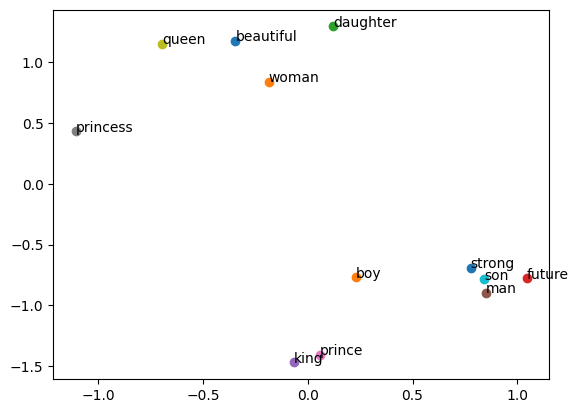

In [82]:
for word in all_words:
    coordinates = word_embedding[word]
    plt.scatter(coordinates[0], coordinates[1])
    plt.annotate(word, (coordinates[0], coordinates[1]))

    